# 04 - Feature importance and stability

**Question:** which sensors drive failures?

Steps:
- Single ranking & showing that it is unstable
- Stability analysis: importance across many resamples
- Notes

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

from src.preprocessing import split_secom, build_preprocessor
from src.stability import bootstrap_importances

In [2]:
X_train, X_test, y_train, y_test = split_secom(test_size=0.20, random_state=42)

# the model carried forward from notebook 03
def make_pipeline():
    return Pipeline([
        ('pre', build_preprocessor()),
        ('clf', RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                       min_samples_leaf=2, random_state=42, n_jobs=-1)),
    ])

print(f'train: {len(X_train)} rows, {y_train.sum()} fails')

train: 1253 rows, 83 fails


## 1. Single ranking

Fit once, read off the feature importances, take the top 15.

In [3]:
pipe = make_pipeline()
pipe.fit(X_train, y_train)

names = pipe.named_steps['pre'].get_feature_names_out()
imp = pd.Series(pipe.named_steps['clf'].feature_importances_, index=names)
top15 = imp.sort_values(ascending=False).head(15)
top15.round(4)

sensor_103    0.0173
sensor_33     0.0164
sensor_59     0.0153
sensor_31     0.0108
sensor_477    0.0091
sensor_213    0.0090
sensor_510    0.0090
sensor_247    0.0089
sensor_130    0.0086
sensor_519    0.0081
sensor_205    0.0078
sensor_351    0.0078
sensor_341    0.0073
sensor_64     0.0067
sensor_319    0.0065
dtype: float64

Single ranking produces a clean list of top-15 important features, but the importances are all low and bunched close together (the top sensor is only ~0.017), so no sensor clearly dominates, which already fits the weak signal seen in notebook 03. With only 83 failures, there's no reason yet to assume this ranking would hold up on a different sample, which we will test by refitting on a few bootstrap resamples of the training data and compare the top-10s (if the ranking is solid, they will mostly agree).

In [4]:
rng = np.random.default_rng(0)
Xr = X_train.reset_index(drop=True); yr = y_train.reset_index(drop=True)

rankings = {}
for r in range(4):
    idx = rng.integers(0, len(Xr), size=len(Xr))
    m = make_pipeline().fit(Xr.iloc[idx], yr.iloc[idx])
    nm = m.named_steps['pre'].get_feature_names_out()
    ser = pd.Series(m.named_steps['clf'].feature_importances_, index=nm)
    rankings[f'resample {r+1}'] = ser.sort_values(ascending=False).head(10).index.tolist()

pd.DataFrame(rankings)

,resample 1,resample 2,resample 3,resample 4
0,sensor_103,sensor_103,sensor_59,sensor_103
1,sensor_125,sensor_477,sensor_103,sensor_0
2,sensor_59,sensor_205,sensor_281,sensor_33
3,sensor_122,sensor_510,sensor_510,sensor_59
4,sensor_129,sensor_59,sensor_213,sensor_16
5,sensor_477,sensor_21,sensor_64,sensor_125
6,sensor_86,sensor_341,sensor_146,sensor_510
7,sensor_205,sensor_33,sensor_14,sensor_64
8,sensor_127,sensor_417,sensor_65,sensor_183
9,sensor_247,sensor_129,sensor_21,sensor_187


Across four resamples the top-10s mostly disagree. A couple of sensors recur near the top (sensor_103 is top-3 in every resample, sensor_59 appears in all four), but the rest of each list is largely different sensors that show up once and vanish. So the clean ranking in section 1 mostly reflected that single fit rather than a real pattern of important features. Next section quantifies this by measuring how often each sensor stays in the top group.

## 2. Stability analysis

Refit on many bootstrap resamples, and for each feature record how *often* it lands in the top-k (`selection_freq`) and how much its importancevaries (`std_importance`).

In [5]:
summary = bootstrap_importances(
    make_pipeline(), X_train, y_train,
    n_resamples=200, top_k=15, random_state=42,
)
print(f"valid resamples: {summary.attrs['n_valid_resamples']}")
summary.head(15).round(4)

valid resamples: 200


,mean_importance,std_importance,selection_freq
sensor_103,0.0161,0.0066,0.915
sensor_59,0.0131,0.0056,0.880
sensor_33,0.0120,0.0046,0.865
sensor_510,0.0080,0.0045,0.515
sensor_477,0.0076,0.0037,0.485
sensor_213,0.0073,0.0033,0.480
sensor_351,0.0070,0.0036,0.460
sensor_130,0.0070,0.0031,0.435
sensor_205,0.0070,0.0037,0.425
sensor_519,0.0070,0.0039,0.425


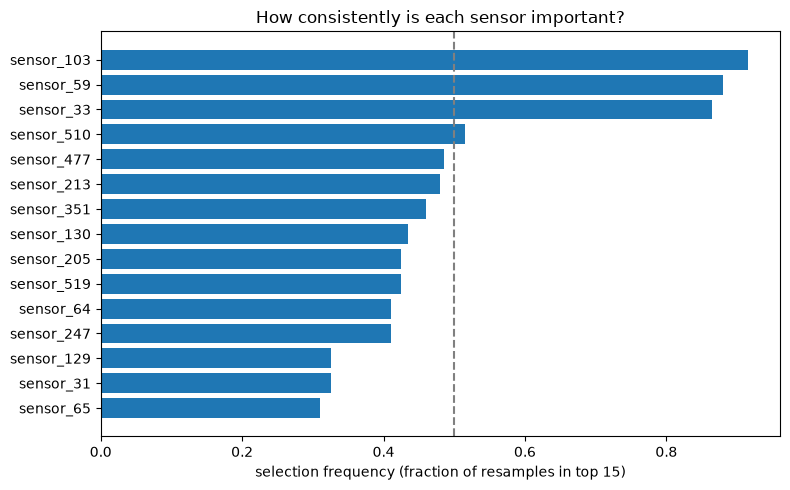

In [6]:
# selection frequency of the top features - how consistent is each?
topn = summary.head(15)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(topn.index[::-1], topn['selection_freq'][::-1])
ax.set_xlabel('selection frequency (fraction of resamples in top 15)')
ax.set_title('How consistently is each sensor important?')
ax.axvline(0.5, ls='--', color='grey')
plt.tight_layout(); plt.show()

Three sensors clear the 0.5 line: sensor_103, sensor_59, and sensor_33, each in the top 15 in roughly 87 to 92 percent of resamples. After those three the selection frequency drops off sharply, and everything else stays below 0.5. So only a small set of sensors is consistently important, and the rest is noise.

## Notes

The three robust sensors (103, 59, 33) are consistently important across resamples, so they're associated with failures (in a way that survives resampling). What this doesn't show is causation: the data is observational and the sensors are anonymised, so there's no basis to say these sensors cause defects, and naming a physical cause would need process knowledge the dataset doesn't carry. And given the weak overall signal from notebook 03, even these three explain only a limited amount, so this points a QC team toward where to look, rather than handing them a root cause.